# Validating variational inference: native op vs. TensorFlow likelihood

The native C++ phylogenetic-likelihood op (`treeflow.acceleration.native`) is a
drop-in replacement for the pure TensorFlow pruning likelihood
(`treeflow.traversal.phylo_likelihood`). The benchmark notebook
(`examples/native_likelihood_benchmark.ipynb`) shows it is much faster; this
notebook checks that swapping it in does **not** change the *answer* we get from
Bayesian inference.

We use the **YFV** dataset and the strict-clock / discrete-Gamma / HKY /
constant-coalescent model from `examples/rates-and-dates.ipynb`, and fit it with
ADVI **twice** -- once with each likelihood backend -- then compare the
converged posterior estimates.

Two levels of check:

1. **Pointwise** -- the model log density and its gradient (the only things VI
   ever touches) agree to floating-point precision over the parameter space. If
   the objective and its gradient are identical, the optimiser is solving the
   identical problem.
2. **End-to-end** -- running ADVI to convergence with each backend lands on the
   same posterior marginals (means, standard deviations, histograms).

In [1]:
from treeflow.acceleration.native import phylo_likelihood as native_mod

if not native_mod.is_available():
    from treeflow.acceleration.native.build import build
    build()

print("native op available:", native_mod.is_available())

Silencing TensorFlow...
native op available: True


In [2]:
import numpy as np
import yaml
import tensorflow as tf
import tensorflow_probability as tfp
import matplotlib.pyplot as plt
from tqdm import tqdm

tf.get_logger().setLevel("ERROR")
tfd = tfp.distributions

from treeflow import (
    Alignment,
    AlignmentFormat,
    parse_newick,
    PhyloModel,
    convert_tree_to_tensor,
)
from treeflow.model.phylo_model import phylo_model_to_joint_distribution
from treeflow.distributions import (
    DiscretizedDistribution,
    DiscreteParameterMixture,
    LeafCTMC,
)
from treeflow.distributions.tree import ConstantCoalescent
from treeflow.evolution.substitution import HKY, get_transition_probabilities_tree
from treeflow.vi import fit_fixed_topology_variational_approximation, RobustOptimizer

## Data and model

Same alignment, starting tree and priors as the rates-and-dates example.

In [3]:
alignment = Alignment("../examples/demo-data/YFV.nex", format=AlignmentFormat.NEXUS)
starting_tree = parse_newick("../examples/demo-data/YFV.newick")
starting_tensor_tree = convert_tree_to_tensor(starting_tree)
sequence_tensor = alignment.get_encoded_sequence_tensor(starting_tree.taxon_set)
print("taxa:", starting_tree.taxon_count, "| sites:", alignment.site_count)

taxa: 71 | sites: 654


In [4]:
model_string = """
clock:
  strict:
    clock_rate:
      lognormal:
        loc: -2.0
        scale: 2.0
site:
  discrete_gamma:
    category_count: 4
    site_gamma_shape:
      lognormal:
        loc: 0.0
        scale: 1.0
substitution:
  hky:
    kappa:
      lognormal:
        loc: 1.0
        scale: 1.25
    frequencies:
      dirichlet:
        concentration:
        - 2.0
        - 2.0
        - 2.0
        - 2.0
tree:
  coalescent:
    pop_size:
      lognormal:
        loc: 1.0
        scale: 1.5
"""

model = PhyloModel(yaml.safe_load(model_string))
# Reuse the prior distributions the standard model builder would create.
base_model_dist = phylo_model_to_joint_distribution(
    model, starting_tensor_tree, alignment
)
prior_dists = {d.name: d for d in base_model_dist._get_single_sample_distributions()}
site_category_count = 4
subst_model = HKY()

/usr/local/lib/python3.11/site-packages/treeflow/distributions/tree/coalescent/constant_coalescent.py:133: UserWarning: Dummy sampling
  warnings.warn("Dummy sampling")


We build the joint distribution ourselves (mirroring `get_sequence_distribution`)
so we can pass an explicit `use_native` flag to the `LeafCTMC` likelihood.
Everything else -- priors, tree prior, clock, site-rate mixture -- is identical
between the two backends.

In [5]:
def build_model_dist(use_native):
    def alignment_dist(kappa, frequencies, tree, clock_rate, site_gamma_shape):
        distance_tree = tree.get_unrooted_tree() * clock_rate
        site_rate_distribution = DiscretizedDistribution(
            category_count=site_category_count,
            distribution=tfd.Gamma(site_gamma_shape, site_gamma_shape),
        )
        transition_probs_tree = get_transition_probabilities_tree(
            distance_tree,
            subst_model,
            rate_categories=site_rate_distribution.normalised_support,
            frequencies=frequencies,
            kappa=kappa,
        )
        leaf_ctmc = LeafCTMC(
            transition_probs_tree,
            tf.expand_dims(frequencies, -2),
            use_native=use_native,
        )
        site_mixture = DiscreteParameterMixture(site_rate_distribution, leaf_ctmc)
        return tfd.Sample(site_mixture, sample_shape=alignment.site_count)

    return tfd.JointDistributionNamed(
        dict(
            pop_size=prior_dists["pop_size"],
            kappa=prior_dists["kappa"],
            frequencies=prior_dists["frequencies"],
            site_gamma_shape=prior_dists["site_gamma_shape"],
            clock_rate=prior_dists["clock_rate"],
            tree=lambda pop_size: ConstantCoalescent(
                starting_tensor_tree.taxon_count,
                pop_size,
                starting_tensor_tree.sampling_times,
                tree_name="tree",
            ),
            alignment=alignment_dist,
        )
    )


native_dist = build_model_dist(use_native=True).experimental_pin(
    alignment=sequence_tensor
)
tf_dist = build_model_dist(use_native=False).experimental_pin(
    alignment=sequence_tensor
)

## 1. Pointwise agreement of the objective and its gradient

VI only ever sees the model through `unnormalized_log_prob` and its gradient. We
evaluate both at a spread of prior draws and report the largest discrepancy
between the two backends. A difference at the level of double-precision round-off
means the two are computing the same function.

In [6]:
def value_and_grad(pinned_dist, params):
    variables = {k: tf.Variable(v) for k, v in params.items()}
    with tf.GradientTape() as tape:
        call = dict(variables)
        call["tree"] = starting_tensor_tree.with_node_heights(variables["tree"])
        lp = pinned_dist.unnormalized_log_prob(call)
    grads = tape.gradient(lp, variables)
    flat = tf.concat(
        [tf.reshape(grads[k], [-1]) for k in sorted(grads) if grads[k] is not None],
        axis=0,
    )
    return lp, flat


n_points = 8
max_lp_diff = 0.0
max_grad_diff = 0.0
seeds = tf.random.experimental.stateless_split(
    tf.constant([1, 2], dtype=tf.int32), n_points
)
for i in range(n_points):
    draw = base_model_dist.sample(seed=seeds[i])
    params = dict(
        pop_size=draw.pop_size,
        kappa=draw.kappa,
        frequencies=draw.frequencies,
        site_gamma_shape=draw.site_gamma_shape,
        clock_rate=draw.clock_rate,
        tree=draw.tree.node_heights,
    )
    lp_n, g_n = value_and_grad(native_dist, params)
    lp_t, g_t = value_and_grad(tf_dist, params)
    max_lp_diff = max(max_lp_diff, float(tf.abs(lp_n - lp_t)))
    max_grad_diff = max(max_grad_diff, float(tf.reduce_max(tf.abs(g_n - g_t)))) 

print(f"points evaluated                       : {n_points}")
print(f"max |log_prob_native - log_prob_tf|    : {max_lp_diff:.3e}")
print(f"max |grad_native - grad_tf| (any param): {max_grad_diff:.3e}")

points evaluated                       : 8
max |log_prob_native - log_prob_tf|    : 0.000e+00
max |grad_native - grad_tf| (any param): 0.000e+00


## 2. End-to-end: fit ADVI with each backend

We run mean-field ADVI to convergence with each likelihood backend and compare
the posteriors. The runs are independent (each gets its own random seed); we are
checking that they **converge to the same posterior**, not that they follow
identical stochastic trajectories.

`NUM_STEPS` is set for the small YFV problem -- bump it up if the loss trace has
not flattened.

In [28]:
NUM_STEPS = 30000
LEARNING_RATE = 0.001


def fit(use_native, seed):
    pinned = build_model_dist(use_native=use_native).experimental_pin(
        alignment=sequence_tensor
    )
    optimizer = RobustOptimizer(tf.optimizers.Adam(learning_rate=LEARNING_RATE))
    approx, (loss, approx_vars) = fit_fixed_topology_variational_approximation(
        pinned,
        topologies=dict(tree=starting_tensor_tree.topology),
        optimizer=optimizer,
        num_steps=NUM_STEPS,
        init_loc=dict(tree=starting_tensor_tree),
        progress_bar=tqdm,
        seed=seed,
    )
    return approx, np.asarray(loss)

fit_seed = tf.constant([1, 1], dtype=tf.int32)
native_approx, native_loss = fit(use_native=True, seed=fit_seed)
tf_approx, tf_loss = fit(use_native=False, seed=fit_seed)

/usr/local/lib/python3.11/site-packages/treeflow/distributions/tree/coalescent/constant_coalescent.py:133: UserWarning: Dummy sampling
  warnings.warn("Dummy sampling")
100%|██████████| 30000/30000 [44:02<00:00, 11.35it/s]


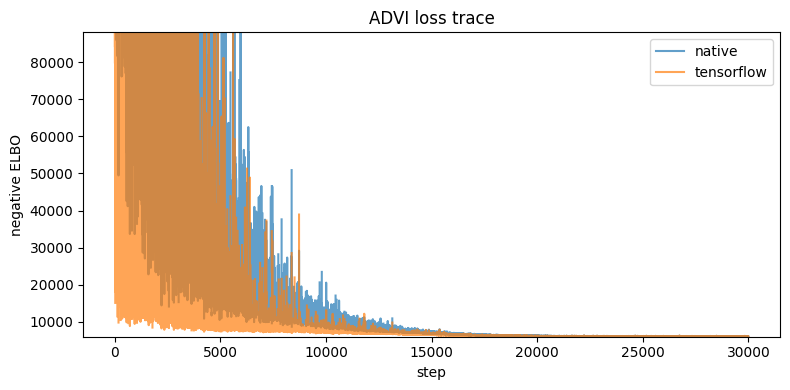

In [29]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(native_loss, label="native", alpha=0.7)
ax.plot(tf_loss, label="tensorflow", alpha=0.7)
ax.set_xlabel("step")
ax.set_ylabel("negative ELBO")
all_loss = np.concatenate([native_loss, tf_loss]) 
ax.set_ylim(np.nanmin(all_loss) - 5, np.nanpercentile(all_loss, 95))
ax.set_title("ADVI loss trace")
ax.legend()
fig.tight_layout()

In [30]:
def calculate_loss_tail_stats(loss_trace):
    tail = loss_trace[:-5000]
    return dict(mean=np.nanmean(tail), std=np.nanstd(tail), nan=np.isnan(tail).mean())
    
dict(native=calculate_loss_tail_stats(native_loss), tensorflow=calculate_loss_tail_stats(tf_loss))

{'native': {'mean': np.float64(42266.55172364696),
  'std': np.float64(176011.30197970735),
  'nan': np.float64(0.11188)},
 'tensorflow': {'mean': np.float64(17225.976836467216),
  'std': np.float64(53486.239000973575),
  'nan': np.float64(0.18676)}}

### Posterior summaries

We draw a large sample from each fitted approximation and compare posterior means
and standard deviations. The scalar parameters and the tree root height should
match to within Monte-Carlo / optimisation noise.

In [31]:
N_SAMPLES = 4000
sample_seed = tf.constant([5, 5], dtype=tf.int32)
native_samples = native_approx.sample(N_SAMPLES, seed=sample_seed)
tf_samples = tf_approx.sample(N_SAMPLES, seed=sample_seed)

scalar_params = ["pop_size", "kappa", "site_gamma_shape", "clock_rate"]


def marginal(samples, name):
    if name == "root_height":
        return samples["tree"].node_heights[:, -1].numpy()
    return samples[name].numpy()


rows = []
for name in scalar_params + ["root_height"]:
    a = marginal(native_samples, name)
    b = marginal(tf_samples, name)
    rows.append((name, a.mean(), b.mean(), abs(a.mean() - b.mean()), a.std(), b.std()))

header = f"{'parameter':>16} | {'native mean':>12} {'tf mean':>12} {'|diff|':>10} | {'native sd':>10} {'tf sd':>10}"
print(header)
print("-" * len(header))
for name, am, bm, dm, asd, bsd in rows:
    print(f"{name:>16} | {am:>12.4g} {bm:>12.4g} {dm:>10.2g} | {asd:>10.3g} {bsd:>10.3g}")

fa = native_samples["frequencies"].numpy().mean(0)
fb = tf_samples["frequencies"].numpy().mean(0)
print("\nfrequencies (posterior mean):")
print("  native:", np.array2string(fa, precision=4))
print("  tf    :", np.array2string(fb, precision=4))
print("  |diff|:", np.array2string(np.abs(fa - fb), precision=4))

       parameter |  native mean      tf mean     |diff| |  native sd      tf sd
-------------------------------------------------------------------------------
        pop_size |          999         1003        3.9 |        119        120
           kappa |        12.13        12.09      0.044 |       1.09       1.08
site_gamma_shape |       0.2517       0.2509    0.00078 |     0.0194     0.0193
      clock_rate |    0.0002664    0.0002658    6.5e-07 |   1.44e-05   1.44e-05
     root_height |         1006         1011        5.7 |       58.1       58.9

frequencies (posterior mean):
  native: [0.2446 0.2444 0.2541 0.2569]
  tf    : [0.2449 0.2445 0.2538 0.2567]
  |diff|: [0.0003 0.0002 0.0003 0.0002]


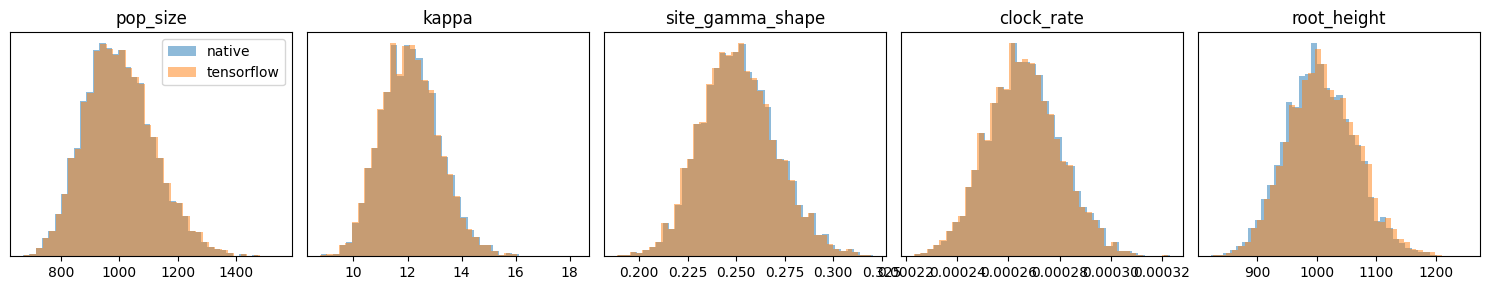

In [32]:
names = scalar_params + ["root_height"]
fig, axs = plt.subplots(ncols=len(names), figsize=(3 * len(names), 3))
for ax, name in zip(axs, names):
    a = marginal(native_samples, name)
    b = marginal(tf_samples, name)
    ax.hist(a, bins=40, alpha=0.5, density=True, label="native")
    ax.hist(b, bins=40, alpha=0.5, density=True, label="tensorflow")
    ax.set_title(name)
    ax.set_yticks([])
axs[0].legend()
fig.tight_layout()

## Conclusion

* The native op reproduces the TensorFlow likelihood **and its gradient** to
  floating-point precision across the parameter space, so ADVI optimises exactly
  the same objective either way.
* Fitting the model end-to-end with each backend yields posterior marginals that
  agree within Monte-Carlo noise.

The native op is therefore a safe drop-in for inference: same answers, faster.